# Load package

In [19]:
import pandas as pd
import numpy as np

import os
import glob

import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_22551/1161626377.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)


In [14]:
core_annotation = data[['core_imageid', 'Annotation']].copy()
core_annotation

,core_imageid,Annotation
CellID,,
1,core77_19_02_02A,Invasive border
10,core77_19_02_01A,Tumor center
10,core77_19_02_02A,Invasive border
100,core77_19_02_01A,Tumor center
100,core77_19_02_02A,Invasive border
...,...,...
99998,core22_INF1,Inflammation
99999,core64_1B,Tumor center
99999,core71_2B,Lymph node met


## All cells

In [103]:
# Path to the folder containing Moran CSV files
moran_folder = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/csv/Moran/'

# Get all CSV files in the folder
moran_files = glob.glob(os.path.join(moran_folder, '*_all.csv'))

# Initialize an empty list to store dataframes
all_moran_dfs = []

for file_path in moran_files:
    # Extract core_imageid from filename
    filename = os.path.basename(file_path)
    core_id = filename.replace('_all.csv', '')
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Select only the marker and I columns
    df_subset = df[['Unnamed: 0', 'I']].copy()
    
    # Rename 'Unnamed: 0' to 'marker'
    df_subset.rename(columns={'Unnamed: 0': 'marker'}, inplace=True)
    
    # Add core_imageid column
    df_subset['core_imageid'] = core_id
    
    # Append to the list of dataframes
    all_moran_dfs.append(df_subset)

# Combine all dataframes
combined_moran = pd.concat(all_moran_dfs, ignore_index=True)

# Create a dictionary mapping core_imageid to annotation
# Using drop_duplicates to handle multiple annotations for the same core
annotation_dict = core_annotation.drop_duplicates('core_imageid').set_index('core_imageid')['Annotation'].to_dict()

# Add Annotation column to combined dataframe
combined_moran['Annotation'] = combined_moran['core_imageid'].map(annotation_dict)
combined_moran['Annotation'] = combined_moran['Annotation'].fillna('Unknown')


<Figure size 500x600 with 0 Axes>

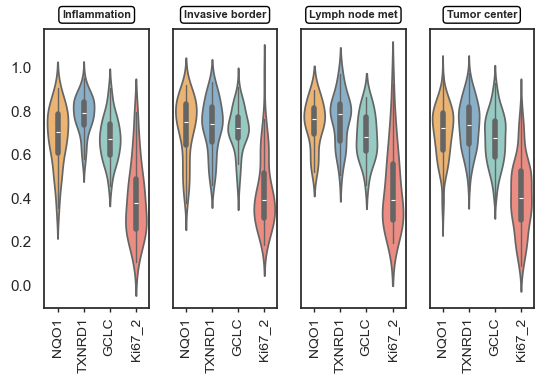

In [104]:

df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['Annotation'] != 'Unknown')]

# Define the custom order for annotations
annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']

# Plot setup
sns.set(style="white")
plt.figure(figsize=(5, 6))

# Violin plot grouped by Region, split by Marker
# Custom color palette for markers
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67_2': '#fc7f71'}

g = sns.catplot(
    x='marker', y='I', hue='marker', #fill=False,
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35, # Further reduced aspect ratio to make plots narrower
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,
)

# Add complete frame around each subplot
for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    # Add tick parameters to ensure tick marks connect to the frame
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)
    #ax.tick_params(axis='y', which='both', length=3, width=1, direction='out', left=True)

# Set titles with a box around them
g.set_titles("{col_name}", fontsize=9, fontweight='bold')

# Add boxes around the titles
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text, 
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')
    
g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_all.pdf', bbox_inches='tight', dpi=500)
plt.show()


## Tumor cells

In [98]:
# Path to the folder containing Moran CSV files
moran_folder = '/Volumes/group/h345/afarkkilab/Data/17_Auria_TMA/csv/Moran/tumor/'

# Get all CSV files in the folder
moran_files = glob.glob(os.path.join(moran_folder, '*_tumor.csv'))

# Initialize an empty list to store dataframes
all_moran_dfs = []

for file_path in moran_files:
    # Extract core_imageid from filename
    filename = os.path.basename(file_path)
    core_id = filename.replace('_tumor.csv', '')
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Select only the marker and I columns
    df_subset = df[['Unnamed: 0', 'I']].copy()
    
    # Rename 'Unnamed: 0' to 'marker'
    df_subset.rename(columns={'Unnamed: 0': 'marker'}, inplace=True)
    
    # Add core_imageid column
    df_subset['core_imageid'] = core_id
    
    # Append to the list of dataframes
    all_moran_dfs.append(df_subset)

# Combine all dataframes
combined_moran = pd.concat(all_moran_dfs, ignore_index=True)

# Create a dictionary mapping core_imageid to annotation
# Using drop_duplicates to handle multiple annotations for the same core
annotation_dict = core_annotation.drop_duplicates('core_imageid').set_index('core_imageid')['Annotation'].to_dict()

# Add Annotation column to combined dataframe
combined_moran['Annotation'] = combined_moran['core_imageid'].map(annotation_dict)
combined_moran['Annotation'] = combined_moran['Annotation'].fillna('Unknown')


In [99]:
combined_moran

,marker,I,core_imageid,Annotation
0,GLUT1,0.864615,core24_19_02_02A,Tumor center
1,GCLC,0.796241,core24_19_02_02A,Tumor center
2,NQO1,0.719143,core24_19_02_02A,Tumor center
3,TXNRD1,0.712005,core24_19_02_02A,Tumor center
4,Vimentin,0.617056,core24_19_02_02A,Tumor center
...,...,...,...,...
2179,GLUT1,0.737137,core24_19_02_01A,Invasive border
2180,GCLC,0.716580,core24_19_02_01A,Invasive border
2181,TXNRD1,0.712921,core24_19_02_01A,Invasive border
2182,Vimentin,0.666361,core24_19_02_01A,Invasive border


In [101]:
df['Annotation'].unique()

array(['Tumor center', 'Inflammation', 'Invasive border',
       'Lymph node met'], dtype=object)

<Figure size 500x600 with 0 Axes>

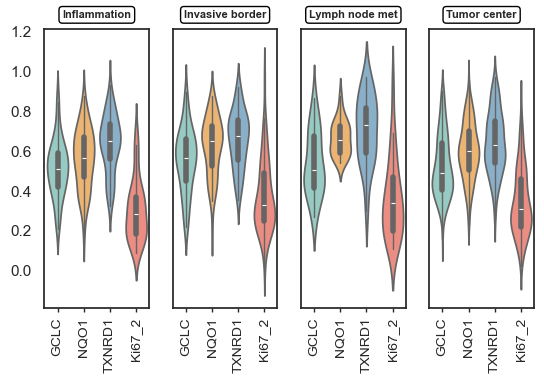

In [102]:

df = pd.DataFrame(combined_moran)
df = df[(df['marker'] != 'GLUT1') & (df['marker'] != 'Vimentin') & (df['Annotation'] != 'Unknown')]

# Define the custom order for annotations
annotation_order = ['Inflammation', 'Invasive border', 'Lymph node met', 'Tumor center']

# Plot setup
sns.set(style="white")
plt.figure(figsize=(5, 6))

# Violin plot grouped by Region, split by Marker
# Custom color palette for markers
marker_colors = {'TXNRD1': '#7fb2d3', 'GCLC': '#8dd3c9', 'NQO1': '#ffb55f', 'Ki67_2': '#fc7f71'}

g = sns.catplot(
    x='marker', y='I', hue='marker', #fill=False,
    col='Annotation', col_wrap=4,
    data=df, kind='violin', split=False, inner='box',
    palette=marker_colors, height=4, aspect=0.35, # Further reduced aspect ratio to make plots narrower
    inner_kws=dict(box_width=4, whis_width=1),
    col_order=annotation_order,  # Use custom order for annotations
)

# Add complete frame around each subplot
for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.grid(False)
    # Add tick parameters to ensure tick marks connect to the frame
    ax.tick_params(axis='x', which='both', length=3, width=1, direction='out', bottom=True)
    #ax.tick_params(axis='y', which='both', length=3, width=1, direction='out', left=True)

# Set titles with a box around them
g.set_titles("{col_name}", fontsize=9, fontweight='bold')

# Add boxes around the titles
for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title('')
    ax.text(0.5, 1.05, title_text, 
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1),
            fontsize=8, fontweight='bold')
    
g.set_axis_labels("", "")
g.set_xticklabels(rotation=90, fontsize=10)

plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Moran_violin_tumor.pdf', bbox_inches='tight', dpi=500)
plt.show()
